In [1]:
import os
print(os.getcwd())

/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis


In [2]:
import sys
for p in sys.path:
    print(p)
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT")


/n/sw/Miniforge3-24.7.1-0/lib/python312.zip
/n/sw/Miniforge3-24.7.1-0/lib/python3.12
/n/sw/Miniforge3-24.7.1-0/lib/python3.12/lib-dynload

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue, \
                              combine_transport_plans, \
                              convert_ensembl_to_gene_symbols, \
                              fetch_human_mouse_one2one_orthologs, \
                              subset_matched_adatas_by_ortholog_table, \
                              align_adatas_biomart_one2one, \
                              strip_ensembl_gene_id, \
                              nearest_neighbor_cell_type, \
                              nn_gene_r2, \
                              plot_ot_transport_by_celltype

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# This counts how many cells each donor has
# Rank donors by cell count, with the most cells first
# Split the data into one AnnData per donor
human_dir = '/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_sapiens/'
human_adatas = top_n_organisms_from_species(human_dir, -1, 'human')
# So this is the 2nd human donor, an anndata object
human1_adata = human_adatas[1]
# convert_ensembl_to_gene_symbols(human1_adata, species="human", make_unique=True)

In [5]:
mouse_dir = '/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/data/tabula_muris/'

mouse_adatas = top_n_organisms_from_species(mouse_dir, -1, 'mouse')
mouse1_adata = mouse_adatas[1]
# convert_ensembl_to_gene_symbols(mouse1_adata, species="mouse", make_unique=True)

In [6]:
print(human1_adata.shape)
mouse1_adata.shape
print(len(human_adatas))
print(len(mouse_adatas))

(8356, 61759)
24
40


In [7]:
import anndata as ad
human_combined = ad.concat(human_adatas, join="outer")
mouse_combined = ad.concat(mouse_adatas, join="outer")

In [8]:
# Outer join takes the union of the 2 sets
print(human_combined.shape)
print(mouse_combined.shape)

(58931, 61759)
(47807, 18024)


In [9]:
# This creates a composite key for every cell
# identity = cell_type_ontology_term_id + "|" + tissue_ontology_term_id
# "CL:0000084|UBERON:0002048" = "T cell from lung"
mouse_matched, human_matched =  match_cells_by_celltype_tissue(mouse_combined, human_combined)

In [10]:
mouse_matched

AnnData object with n_obs × n_vars = 6495 × 18024
    obs: 'batch', 'tissue_FACS_droplet', 'free_annotation', 'n_counts', 'n_genes', 'louvain', 'leiden', 'age', 'method', 'donor_id', 'subtissue', 'tissue_free_annotation', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'FACS.selection', 'tissue_original', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'shared_cell_type'
    obsm: 'X_pca', 'X_umap'

In [11]:
mouse_matched.obs[['cell_type_ontology_term_id','tissue_ontology_term_id']].value_counts()

cell_type_ontology_term_id  tissue_ontology_term_id
CL:0000037                  UBERON:0002371             792
CL:0008001                  UBERON:0002371             792
CL:0002393                  UBERON:0002048             504
CL:0000893                  UBERON:0002370             455
CL:0000875                  UBERON:0002048             426
                                                      ... 
CL:0000084                  UBERON:0002107               2
CL:0000576                  UBERON:0000948               2
CL:0000232                  UBERON:0000948               1
CL:0000084                  UBERON:0003126               1
CL:0000624                  UBERON:0002107               1
Name: count, Length: 75, dtype: int64

In [12]:
# cell_type_key: str = "cell_type_ontology_term_id",
# tissue_key: str = "tissue_ontology_term_id",
# ontology has to do with the meaning and relationship between things, a constructed tree
# each node in the tree will have an identifier, across different levels
# there are packages to check the parent and children of an identifier
# if a mouse cell is taken and examine their tissue and cell, no match, then we can take a look at the children or parents of that node
# Shared cell type

# Cell type in mouse and human are called differently but to describe the same thing, but ontology identifier is unique
# Leave out all cell from one cell type ontology id
# cell_type_ontology_term_id
# Primary cell ontology for a natrual regulatory T cell is CL:0000903, confirm on that!!!
# If there are a lot of them,  maybe we can take a look at tissues

# IID setting is the easier problem, let us train on both mouse and humans then
# Recreate how it would work
# LPS6 in their condition
# # Show all unique conditions to understand LPS timepoints
# print('All unique condition labels:')
# print(sorted(adata.obs['condition'].unique()))

# Concatenate the human and mouse dataset into a single anndata frame
# Probably some preprocessing, and this preprocessing proabbly come from the paper that maintain the daaset
# add the condition: 

In [13]:
human_matched

AnnData object with n_obs × n_vars = 6495 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'deve

In [14]:
# We should see mouse_matched and human_matched having the same number of cells
human_matched.obs[['cell_type_ontology_term_id','tissue_ontology_term_id']].value_counts()

cell_type_ontology_term_id  tissue_ontology_term_id
CL:0000037                  UBERON:0002371             792
CL:0008001                  UBERON:0002371             792
CL:0002393                  UBERON:0002048             504
CL:0000893                  UBERON:0002370             455
CL:0000875                  UBERON:0002048             426
                                                      ... 
CL:0000084                  UBERON:0002107               2
CL:0000576                  UBERON:0000948               2
CL:0000232                  UBERON:0000948               1
CL:0000084                  UBERON:0003126               1
CL:0000624                  UBERON:0002107               1
Name: count, Length: 75, dtype: int64

In [15]:
# Examine whether the data is sparse or not, and whether it is normalized or not
from scipy import sparse
X = human_matched.X
print(f"Type: {type(X)}")
print(f"Sparse: {sparse.issparse(X)}")
if sparse.issparse(X):
    print(f"Sparsity: {1 - X.nnz / np.prod(X.shape):.2%}")
    X_dense = X.toarray()
else:
    X_dense = X

print(f"\nValue range: [{X_dense.min():.3f}, {X_dense.max():.3f}]")
print(f"Mean: {X_dense.mean():.3f}, Std: {X_dense.std():.3f}")
print(f"Fraction of zeros: {(X_dense == 0).mean():.2%}")

Type: <class 'scipy.sparse._csr.csr_matrix'>
Sparse: True
Sparsity: 94.44%

Value range: [0.000, 8.968]
Mean: 0.054, Std: 0.275
Fraction of zeros: 94.44%


In [16]:
X = mouse_matched.X
print(f"Type: {type(X)}")
print(f"Sparse: {sparse.issparse(X)}")
if sparse.issparse(X):
    print(f"Sparsity: {1 - X.nnz / np.prod(X.shape):.2%}")
    X_dense = X.toarray()
else:
    X_dense = X

print(f"\nValue range: [{X_dense.min():.3f}, {X_dense.max():.3f}]")
print(f"Mean: {X_dense.mean():.3f}, Std: {X_dense.std():.3f}")
print(f"Fraction of zeros: {(X_dense == 0).mean():.2%}")

Type: <class 'scipy.sparse._csr.csr_matrix'>
Sparse: True
Sparsity: 87.65%

Value range: [0.000, 10.000]
Mean: 0.263, Std: 0.914
Fraction of zeros: 87.65%


In [17]:
# This is a high level table containing all composite keys
# cell_type_ontology_term_id | tissue_ontology_term_id
# Total 6418 matched cells

cell_type_ontology_term_id | tissue_ontology_term_id Combined Table

In [18]:
# ==============================================================================
# TABLE A: Composite-Key Summary Tables
# ==============================================================================
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 40)

# Build composite keys on the matched data
m_obs = mouse_matched.obs.copy()
h_obs = human_matched.obs.copy()
m_obs['composite_key'] = (
    m_obs['cell_type_ontology_term_id'].astype(str) + '|' +
    m_obs['tissue_ontology_term_id'].astype(str)
)
h_obs['composite_key'] = (
    h_obs['cell_type_ontology_term_id'].astype(str) + '|' +
    h_obs['tissue_ontology_term_id'].astype(str)
)

# --- Per-species summary tables ---
def species_summary(obs_df):
    return (
        obs_df.groupby('composite_key')
        .agg(
            cell_type_id=('cell_type_ontology_term_id', 'first'),
            cell_type=('cell_type', 'first'),
            tissue_id=('tissue_ontology_term_id', 'first'),
            tissue=('tissue', 'first'),
            count=('composite_key', 'size'),
        )
        .sort_values('count', ascending=False)
        .reset_index()
    )

mouse_matched_summary = species_summary(m_obs)
human_matched_summary = species_summary(h_obs)

print("=" * 90)
print("MOUSE1 SUMMARY  (matched cells only)")
print("=" * 90)
display(mouse_matched_summary)

print("\n" + "=" * 90)
print("HUMAN1 SUMMARY  (matched cells only)")
print("=" * 90)
display(human_matched_summary)

# --- Combined / side-by-side summary ---
mc = mouse_combined.obs.copy()
hc = human_combined.obs.copy()
mc['composite_key'] = mc['cell_type_ontology_term_id'].astype(str) + '|' + mc['tissue_ontology_term_id'].astype(str)
hc['composite_key'] = hc['cell_type_ontology_term_id'].astype(str) + '|' + hc['tissue_ontology_term_id'].astype(str)

table_a = (
    mouse_matched_summary[['composite_key', 'cell_type_id', 'cell_type', 'tissue_id', 'tissue']]
    .rename(columns={'cell_type': 'cell_type_mouse', 'tissue': 'tissue_mouse'})
    .merge(
        human_matched_summary[['composite_key', 'cell_type', 'tissue']]
        .rename(columns={'cell_type': 'cell_type_human', 'tissue': 'tissue_human'}),
        on='composite_key',
    )
)

n_keep_series = m_obs['composite_key'].value_counts()
table_a['n_keep'] = table_a['composite_key'].map(n_keep_series).astype(int)

mouse_pool = mc['composite_key'].value_counts().rename('mouse_cell_count_full')
human_pool = hc['composite_key'].value_counts().rename('human_cell_count_full')
table_a = table_a.set_index('composite_key').join(mouse_pool).join(human_pool).reset_index()
table_a[['mouse_cell_count_full', 'human_cell_count_full']] = (
    table_a[['mouse_cell_count_full', 'human_cell_count_full']].fillna(0).astype(int)
)
table_a = table_a.sort_values('n_keep', ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("COMBINED SUMMARY  (composite key = cell_type_ontology | tissue_ontology)")
print("=" * 90)
print(f"Unique composite keys: {len(table_a)}")
print(f"Total matched cells per species: {table_a['n_keep'].sum()}")
display(table_a)

MOUSE1 SUMMARY  (matched cells only)


,composite_key,cell_type_id,cell_type,tissue_id,tissue,count
0,CL:0000037|UBERON:0002371,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,792
1,CL:0008001|UBERON:0002371,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,792
2,CL:0002393|UBERON:0002048,CL:0002393,intermediate monocyte,UBERON:0002048,lung,504
3,CL:0000893|UBERON:0002370,CL:0000893,thymocyte,UBERON:0002370,thymus,455
4,CL:0000875|UBERON:0002048,CL:0000875,non-classical monocyte,UBERON:0002048,lung,426
5,CL:1000320|UBERON:0000059,CL:1000320,large intestine goblet cell,UBERON:0000059,large intestine,380
6,CL:0002063|UBERON:0002048,CL:0002063,pulmonary alveolar type 2 cell,UBERON:0002048,lung,292
7,CL:0002543|UBERON:0002048,CL:0002543,vein endothelial cell,UBERON:0002048,lung,287
8,CL:0002548|UBERON:0000948,CL:0002548,fibroblast of cardiac tissue,UBERON:0000948,heart,242
9,CL:0002598|UBERON:0002048,CL:0002598,bronchial smooth muscle cell,UBERON:0002048,lung,220



HUMAN1 SUMMARY  (matched cells only)


,composite_key,cell_type_id,cell_type,tissue_id,tissue,count
0,CL:0000037|UBERON:0002371,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,792
1,CL:0008001|UBERON:0002371,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,792
2,CL:0002393|UBERON:0002048,CL:0002393,intermediate monocyte,UBERON:0002048,lung,504
3,CL:0000893|UBERON:0002370,CL:0000893,thymocyte,UBERON:0002370,thymus,455
4,CL:0000875|UBERON:0002048,CL:0000875,non-classical monocyte,UBERON:0002048,lung,426
5,CL:1000320|UBERON:0000059,CL:1000320,large intestine goblet cell,UBERON:0000059,large intestine,380
6,CL:0002063|UBERON:0002048,CL:0002063,pulmonary alveolar type 2 cell,UBERON:0002048,lung,292
7,CL:0002543|UBERON:0002048,CL:0002543,vein endothelial cell,UBERON:0002048,lung,287
8,CL:0002548|UBERON:0000948,CL:0002548,fibroblast of cardiac tissue,UBERON:0000948,heart,242
9,CL:0002598|UBERON:0002048,CL:0002598,bronchial smooth muscle cell,UBERON:0002048,lung,220



COMBINED SUMMARY  (composite key = cell_type_ontology | tissue_ontology)
Unique composite keys: 75
Total matched cells per species: 6495


,composite_key,cell_type_id,cell_type_mouse,tissue_id,tissue_mouse,cell_type_human,tissue_human,n_keep,mouse_cell_count_full,human_cell_count_full
0,CL:0000037|UBERON:0002371,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,hematopoietic stem cell,bone marrow,792,993,792
1,CL:0008001|UBERON:0002371,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,hematopoietic precursor cell,bone marrow,792,1000,792
2,CL:0002393|UBERON:0002048,CL:0002393,intermediate monocyte,UBERON:0002048,lung,intermediate monocyte,lung,504,1000,504
3,CL:0000893|UBERON:0002370,CL:0000893,thymocyte,UBERON:0002370,thymus,thymocyte,thymus,455,1000,455
4,CL:0000875|UBERON:0002048,CL:0000875,non-classical monocyte,UBERON:0002048,lung,non-classical monocyte,lung,426,1000,426
5,CL:1000320|UBERON:0000059,CL:1000320,large intestine goblet cell,UBERON:0000059,large intestine,large intestine goblet cell,large intestine,380,1000,380
6,CL:0002063|UBERON:0002048,CL:0002063,pulmonary alveolar type 2 cell,UBERON:0002048,lung,pulmonary alveolar type 2 cell,lung,292,292,1000
7,CL:0002543|UBERON:0002048,CL:0002543,vein endothelial cell,UBERON:0002048,lung,vein endothelial cell,lung,287,472,287
8,CL:0002548|UBERON:0000948,CL:0002548,fibroblast of cardiac tissue,UBERON:0000948,heart,fibroblast of cardiac tissue,heart,242,974,242
9,CL:0002598|UBERON:0002048,CL:0002598,bronchial smooth muscle cell,UBERON:0002048,lung,bronchial smooth muscle cell,lung,220,1000,220


cell_type_ontology_term_id | tissue_ontology_term_id Individually Matched Table

In [19]:
# ==============================================================================
# TABLE B: Per-Composite-Key Detail  (mouse on top, human below)
# ==============================================================================
SHOW_COLS = ['species', 'cell_type_ontology_term_id', 'cell_type',
             'tissue_ontology_term_id', 'tissue', 'donor_id']
for col in ['method', 'free_annotation']:
    if col in mouse_matched.obs.columns and col in human_matched.obs.columns:
        SHOW_COLS.append(col)

m_disp = m_obs.copy()
h_disp = h_obs.copy()
m_disp['species'] = 'mouse'
h_disp['species'] = 'human'

avail = [c for c in SHOW_COLS if c in m_disp.columns and c in h_disp.columns]

MAX_PER_SPECIES = 20

for _, row in table_a.iterrows():
    key = row['composite_key']
    ms = m_disp.loc[m_disp['composite_key'] == key, avail]
    hs = h_disp.loc[h_disp['composite_key'] == key, avail]

    print(f"\n{'=' * 90}")
    print(f"  {key}")
    print(f"  Cell type (mouse): {row['cell_type_mouse']}")
    print(f"  Cell type (human): {row['cell_type_human']}")
    print(f"  Tissue    (mouse): {row['tissue_mouse']}")
    print(f"  Tissue    (human): {row['tissue_human']}")
    print(f"  Mouse: {len(ms)} cells  |  Human: {len(hs)} cells")

    if 'donor_id' in ms.columns:
        print(f"  Mouse donors: {dict(ms['donor_id'].value_counts())}")
    if 'donor_id' in hs.columns:
        print(f"  Human donors: {dict(hs['donor_id'].value_counts())}")
    print(f"{'=' * 90}")

    m_show = ms.head(MAX_PER_SPECIES)
    h_show = hs.head(MAX_PER_SPECIES)
    stacked = pd.concat([m_show, h_show], ignore_index=True)
    display(stacked)

    trunc = []
    if len(ms) > MAX_PER_SPECIES:
        trunc.append(f"mouse: {MAX_PER_SPECIES}/{len(ms)}")
    if len(hs) > MAX_PER_SPECIES:
        trunc.append(f"human: {MAX_PER_SPECIES}/{len(hs)}")
    if trunc:
        print(f"  ... showing {', '.join(trunc)}")


  CL:0000037|UBERON:0002371
  Cell type (mouse): hematopoietic stem cell
  Cell type (human): hematopoietic stem cell
  Tissue    (mouse): bone marrow
  Tissue    (human): bone marrow
  Mouse: 792 cells  |  Human: 792 cells
  Mouse donors: {'3_8_M': np.int64(80), '24_61_M': np.int64(79), '24_60_M': np.int64(77), '18_53_M': np.int64(72), '3_9_M': np.int64(71), '18_46_F': np.int64(66), '24_59_M': np.int64(65), '24_58_M': np.int64(64), '3_10_M': np.int64(62), '3_38_F': np.int64(53), '18_47_F': np.int64(52), '3_39_F': np.int64(51), '1-M-62': np.int64(0), '3-M-5/6': np.int64(0), '3-F-57': np.int64(0), '3-F-56': np.int64(0), '1-M-63': np.int64(0), '3_38_F/3_39_F': np.int64(0), '3_11_M': np.int64(0), '3-M-7/8': np.int64(0), '3-M-8': np.int64(0), '18_45_M': np.int64(0), '18-M-53': np.int64(0), '18-M-52': np.int64(0), '18-F-51': np.int64(0), '3_56_F': np.int64(0), '18-F-50': np.int64(0), '21-F-54': np.int64(0), '21-F-55': np.int64(0), '24-M-61': np.int64(0), '24-M-60': np.int64(0), '24-M-59': 

,species,cell_type_ontology_term_id,cell_type,tissue_ontology_term_id,tissue,donor_id,method,free_annotation
0,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,18_53_M,facs,MPP Fraction B + C
1,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,24_60_M,facs,MPP Fraction B
2,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,3_38_F,facs,MPP Fraction B
3,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,24_61_M,facs,MPP Fraction B
4,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,24_58_M,facs,MPP Fraction A + HSC
5,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,24_60_M,facs,MPP Fraction B
6,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,24_59_M,facs,MPP Fraction B
7,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,3_8_M,facs,MPP Fraction A + HSC
8,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,18_53_M,facs,MPP Fraction B + C
9,mouse,CL:0000037,hematopoietic stem cell,UBERON:0002371,bone marrow,24_61_M,facs,MPP Fraction A + HSC


  ... showing mouse: 20/792, human: 20/792

  CL:0008001|UBERON:0002371
  Cell type (mouse): hematopoietic precursor cell
  Cell type (human): hematopoietic precursor cell
  Tissue    (mouse): bone marrow
  Tissue    (human): bone marrow
  Mouse: 792 cells  |  Human: 792 cells
  Mouse donors: {'30-M-5': np.int64(69), '24-M-58': np.int64(68), '21-F-54': np.int64(66), '21-F-55': np.int64(63), '30-M-3': np.int64(63), '3-F-56': np.int64(62), '24-M-59': np.int64(62), '30-M-2': np.int64(51), '3-F-57': np.int64(46), '18-F-51': np.int64(41), '18-F-50': np.int64(40), '24-M-60': np.int64(39), '18-M-52': np.int64(35), '1-M-63': np.int64(34), '1-M-62': np.int64(26), '24-M-61': np.int64(21), '18-M-53': np.int64(6), '3-M-5/6': np.int64(0), '3-M-7/8': np.int64(0), '3_8_M': np.int64(0), '3-M-8': np.int64(0), '18_46_F': np.int64(0), '18_45_M': np.int64(0), '3_56_F': np.int64(0), '3_39_F': np.int64(0), '3_10_M': np.int64(0), '3_11_M': np.int64(0), '3_38_F': np.int64(0), '3_38_F/3_39_F': np.int64(0), '3_

,species,cell_type_ontology_term_id,cell_type,tissue_ontology_term_id,tissue,donor_id,method,free_annotation
0,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,30-M-3,droplet,nan
1,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,24-M-61,droplet,nan
2,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,3-F-56,droplet,nan
3,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,3-F-56,droplet,nan
4,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,24-M-58,droplet,nan
5,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,30-M-5,droplet,nan
6,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,24-M-59,droplet,nan
7,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,3-F-56,droplet,nan
8,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,18-F-50,droplet,nan
9,mouse,CL:0008001,hematopoietic precursor cell,UBERON:0002371,bone marrow,21-F-55,droplet,nan


  ... showing mouse: 20/792, human: 20/792

  CL:0002393|UBERON:0002048
  Cell type (mouse): intermediate monocyte
  Cell type (human): intermediate monocyte
  Tissue    (mouse): lung
  Tissue    (human): lung
  Mouse: 504 cells  |  Human: 504 cells
  Mouse donors: {'30-M-2': np.int64(390), '30-M-3': np.int64(30), '1-M-62': np.int64(21), '1-M-63': np.int64(19), '18-M-53': np.int64(10), '18-M-52': np.int64(7), '3-F-57': np.int64(6), '18-F-51': np.int64(5), '30-M-4': np.int64(4), '30-M-5': np.int64(4), '21-F-55': np.int64(3), '3_8_M': np.int64(2), '3-F-56': np.int64(1), '3_9_M': np.int64(1), '3_10_M': np.int64(1), '3-M-5/6': np.int64(0), '3_11_M': np.int64(0), '3_38_F/3_39_F': np.int64(0), '3_38_F': np.int64(0), '3-M-7/8': np.int64(0), '3-M-8': np.int64(0), '18_46_F': np.int64(0), '18_45_M': np.int64(0), '3_56_F': np.int64(0), '18-F-50': np.int64(0), '3_39_F': np.int64(0), '18_47_F': np.int64(0), '18_53_M': np.int64(0), '21-F-54': np.int64(0), '24-M-61': np.int64(0), '24-M-60': np.int64(

...

,species,cell_type_ontology_term_id,cell_type,tissue_ontology_term_id,tissue,donor_id,method,free_annotation
0,mouse,CL:0000232,erythrocyte,UBERON:0000948,heart,24-M-59,droplet,red blood cell
1,human,CL:0000232,erythrocyte,UBERON:0000948,heart,TSP21,10X,erythrocyte



  CL:0000084|UBERON:0003126
  Cell type (mouse): T cell
  Cell type (human): T cell
  Tissue    (mouse): trachea
  Tissue    (human): trachea
  Mouse: 1 cells  |  Human: 1 cells
  Mouse donors: {'24_60_M': np.int64(1), '1-M-63': np.int64(0), '3-F-56': np.int64(0), '3-F-57': np.int64(0), '1-M-62': np.int64(0), '3-M-5/6': np.int64(0), '3-M-7/8': np.int64(0), '3_8_M': np.int64(0), '3-M-8': np.int64(0), '3_10_M': np.int64(0), '3_11_M': np.int64(0), '3_38_F': np.int64(0), '3_9_M': np.int64(0), '3_39_F': np.int64(0), '3_56_F': np.int64(0), '18-F-50': np.int64(0), '18-F-51': np.int64(0), '18-M-52': np.int64(0), '18-M-53': np.int64(0), '18_45_M': np.int64(0), '3_38_F/3_39_F': np.int64(0), '18_46_F': np.int64(0), '18_47_F': np.int64(0), '21-F-54': np.int64(0), '18_53_M': np.int64(0), '24-M-58': np.int64(0), '24-M-59': np.int64(0), '24-M-60': np.int64(0), '21-F-55': np.int64(0), '24-M-61': np.int64(0), '24_58_M': np.int64(0), '24_59_M': np.int64(0), '24_61_M': np.int64(0), '30-M-2': np.int64(0)

,species,cell_type_ontology_term_id,cell_type,tissue_ontology_term_id,tissue,donor_id,method,free_annotation
0,mouse,CL:0000084,T cell,UBERON:0003126,trachea,24_60_M,facs,nan
1,human,CL:0000084,T cell,UBERON:0003126,trachea,TSP6,10X,t cell



  CL:0000624|UBERON:0002107
  Cell type (mouse): CD4-positive, alpha-beta T cell
  Cell type (human): CD4-positive, alpha-beta T cell
  Tissue    (mouse): liver
  Tissue    (human): liver
  Mouse: 1 cells  |  Human: 1 cells
  Mouse donors: {'24_59_M': np.int64(1), '1-M-63': np.int64(0), '3-F-56': np.int64(0), '3-F-57': np.int64(0), '1-M-62': np.int64(0), '3-M-5/6': np.int64(0), '3-M-7/8': np.int64(0), '3_8_M': np.int64(0), '3-M-8': np.int64(0), '3_10_M': np.int64(0), '3_11_M': np.int64(0), '3_38_F': np.int64(0), '3_9_M': np.int64(0), '3_39_F': np.int64(0), '3_56_F': np.int64(0), '18-F-50': np.int64(0), '18-F-51': np.int64(0), '18-M-52': np.int64(0), '18-M-53': np.int64(0), '18_45_M': np.int64(0), '3_38_F/3_39_F': np.int64(0), '18_46_F': np.int64(0), '18_47_F': np.int64(0), '21-F-54': np.int64(0), '18_53_M': np.int64(0), '24-M-58': np.int64(0), '24-M-59': np.int64(0), '24-M-60': np.int64(0), '21-F-55': np.int64(0), '24-M-61': np.int64(0), '24_58_M': np.int64(0), '24_60_M': np.int64(0),

,species,cell_type_ontology_term_id,cell_type,tissue_ontology_term_id,tissue,donor_id,method,free_annotation
0,mouse,CL:0000624,"CD4-positive, alpha-beta T cell",UBERON:0002107,liver,24_59_M,facs,nan
1,human,CL:0000624,"CD4-positive, alpha-beta T cell",UBERON:0002107,liver,TSP14,10X,t cell


In [20]:
# Downlaod the cell ontology which is a public standardized vocab
# where every cell type has an ID, CL:0000084 = T cell
#[Term]
#id: CL:0000084
#name: T cell
#is_a: CL:0000542 ! lymphocyte

# The root of the cell is CL:0000000
# For each cell type ID, compute the shorteset path to the root

# For example:

# CL:0000000 cell → depth 0 (root)
# CL:0000542 lymphocyte → depth ~3
# CL:0000084 T cell → depth ~4
# CL:0000903 natural regulatory T cell → depth ~6

# Find parent terms, immediate parent, which gives us the context
# CL:0000084 T cell → parent terms: CL:0000542 ! lymphocyte
# CL:0000903 natural regulatory T cell → parent terms: CL:0000084 ! T cell


#There are some depth that are not found which shows NaN

Ontology Depth Table

In [21]:
# ==============================================================================
# ONTOLOGY DEPTH: CL term depth from root  (deeper = more granular)
# ==============================================================================
import networkx as nx
import urllib.request, io

def parse_obo_to_graph(url):
    """Minimal OBO parser -> networkx DiGraph with is_a edges (child -> parent)."""
    print(f"Downloading {url} ...")
    with urllib.request.urlopen(url) as resp:
        text = resp.read().decode('utf-8')

    G = nx.DiGraph()
    current_id = None
    current_name = None
    in_term = False

    for line in text.splitlines():
        line = line.strip()
        if line == '[Term]':
            in_term = True
            current_id = None
            current_name = None
        elif line.startswith('[') and line.endswith(']'):
            in_term = False
        elif in_term:
            if line.startswith('id: '):
                current_id = line[4:].strip()
                G.add_node(current_id)
            elif line.startswith('name: '):
                current_name = line[6:].strip()
                if current_id:
                    G.nodes[current_id]['name'] = current_name
            elif line.startswith('is_a: '):
                parent_id = line[6:].split('!')[0].strip()
                if current_id:
                    G.add_edge(current_id, parent_id)
    return G

CL_OBO_URL = 'http://purl.obolibrary.org/obo/cl.obo'
ROOT = 'CL:0000000'

graph = parse_obo_to_graph(CL_OBO_URL)
print(f"  Loaded: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

id_to_name = {nid: data.get('name', nid) for nid, data in graph.nodes(data=True)}

unique_ct_ids = table_a['cell_type_id'].unique()
depth_map = {}
parent_map = {}

for ct_id in unique_ct_ids:
    try:
        depth_map[ct_id] = nx.shortest_path_length(graph, source=ct_id, target=ROOT)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        depth_map[ct_id] = None

    parents = [
        f"{p} ({id_to_name.get(p, '?')})"
        for _, p in graph.out_edges(ct_id)
    ]
    parent_map[ct_id] = '; '.join(parents) if parents else 'root / not found'

table_a['ontology_depth'] = table_a['cell_type_id'].map(depth_map)
table_a['parent_terms'] = table_a['cell_type_id'].map(parent_map)

print("\nComposite keys with ontology depth  (lower = broader, higher = more granular):")
depth_view = table_a[
    ['cell_type_id', 'cell_type_mouse', 'tissue_mouse',
     'n_keep', 'ontology_depth', 'parent_terms']
].sort_values('ontology_depth', ascending=True)
display(depth_view)

print("\nInterpretation:")
print("  - Holding out a BROAD (low-depth) cell type is a harder OOD test")
print("    because the model loses an entire branch of the cell-type tree.")
print("  - Holding out a GRANULAR (high-depth) cell type is easier because")
print("    closely related types remain in training.")

  Loaded: 19594 nodes, 28819 edges

Composite keys with ontology depth  (lower = broader, higher = more granular):


,cell_type_id,cell_type_mouse,tissue_mouse,n_keep,ontology_depth,parent_terms
0,CL:0000037,hematopoietic stem cell,bone marrow,792,2.0,CL:0000255 (eukaryotic cell); CL:000...
1,CL:0008001,hematopoietic precursor cell,bone marrow,792,2.0,CL:0000988 (hematopoietic cell)
16,CL:0000115,endothelial cell,adipose tissue,89,2.0,BFO:0000002 (BFO:0000002); CL:000025...
20,CL:0000669,pericyte,lung,67,2.0,CL:0000183 (contractile cell); CL:00...
24,CL:0000115,endothelial cell,mammary gland,46,2.0,BFO:0000002 (BFO:0000002); CL:000025...
37,CL:0000115,endothelial cell,subcutaneous adipose tissue,20,2.0,BFO:0000002 (BFO:0000002); CL:000025...
33,CL:0000115,endothelial cell,brown adipose tissue,25,2.0,BFO:0000002 (BFO:0000002); CL:000025...
35,CL:0000115,endothelial cell,trachea,23,2.0,BFO:0000002 (BFO:0000002); CL:000025...
72,CL:0000232,erythrocyte,heart,1,2.0,CL:0000081 (blood cell); CL:0000329 ...
19,CL:0000576,monocyte,bone marrow,81,3.0,CL:0000113 (mononuclear phagocyte); ...



Interpretation:
  - Holding out a BROAD (low-depth) cell type is a harder OOD test
    because the model loses an entire branch of the cell-type tree.
  - Holding out a GRANULAR (high-depth) cell type is easier because
    closely related types remain in training.


In [22]:
# Basic Preprocessing: The dataset was first filtered for cells, normalized, 
# and then log-transformed.

# Ortholog Mapping (The Cross-Species Alignment): 
# To ensure the model could compare the exact same genes across 
# four different animal genomes, 
# the authors used a tool called BiomaRt (v.84). 

# They used this tool to find the ENSEMBL IDs of "one-to-one orthologs" in the rat, 
# rabbit, and pig genomes 
# that directly correspond with the mouse genome.


# Final Feature Space: By filtering down to only these shared one-to-one orthologs, 
# they established a uniform feature space. In total, 6,619 shared genes were selected from all species to train the model.


# Total Cell Count: After this preprocessing and ortholog alignment, the final combined dataset included 77,642 cells

In [23]:
# Mouse:18024
# Human:61759
# Coded in Ensembl, need to convert to gene symbols
# The AE needs one fixed input dimension

# Via mygene API into human readable 
# ENSMUSG00000051951 → Xkr4, ENSG00000141510 → TP53
# Find genes in both species, pay attention to case sensitivity

# Subset both datasets to only shared orthologs
# orthologs genes fronm different species that arise from the same ancestral gene
# Should have identical gene columns (14633)


# There are  lot of them that are excluded due to the approach that I am using here
# Name matching can be unreliable
# mouse_human_orthologs_biomart
# Use this instead

Gene Space Alignment Using Biomart

In [24]:
# ==============================================================================
# GENE SPACE ALIGNMENT  (BioMart one-to-one orthologs, or mygene+symbol fallback)
# ==============================================================================
print("Current var_names format:")
print(f"  Mouse (first 5): {list(mouse_matched.var_names[:5])}")
print(f"  Human (first 5): {list(human_matched.var_names[:5])}")
print(f"  Mouse total genes: {mouse_matched.n_vars}")
print(f"  Human total genes: {human_matched.n_vars}")

mouse_is_ensembl = any(str(g).upper().startswith('ENSMUSG') for g in mouse_matched.var_names[:20])
human_is_ensembl = any(str(g).upper().startswith('ENSG') for g in human_matched.var_names[:20])
print(f"\n  Mouse uses Ensembl IDs: {mouse_is_ensembl}")
print(f"  Human uses Ensembl IDs: {human_is_ensembl}")

if mouse_is_ensembl and human_is_ensembl:
    print("\nAligning genes via Ensembl BioMart one-to-one orthologs (pybiomart; same query as e14) ...")
    mouse_shared, human_shared, ortholog_table = align_adatas_biomart_one2one(mouse_matched, human_matched)
    print(f"  Ortholog pairs kept (overlap with both datasets): {len(ortholog_table)}")
else:
    print("\nFallback: mygene Ensembl→symbol, then case-insensitive symbol intersection ...")
    mouse_aligned = mouse_matched.copy()
    human_aligned = human_matched.copy()

    if mouse_is_ensembl:
        print("\nConverting mouse Ensembl IDs -> gene symbols (via mygene) ...")
        convert_ensembl_to_gene_symbols(mouse_aligned, species="mouse", make_unique=True)

    if human_is_ensembl:
        print("Converting human Ensembl IDs -> gene symbols (via mygene) ...")
        convert_ensembl_to_gene_symbols(human_aligned, species="human", make_unique=True)

    print(f"\nAfter conversion:")
    print(f"  Mouse var_names (first 5): {list(mouse_aligned.var_names[:5])}")
    print(f"  Human var_names (first 5): {list(human_aligned.var_names[:5])}")

    mouse_upper = {str(g).upper(): str(g) for g in mouse_aligned.var_names}
    human_upper = {str(g).upper(): str(g) for g in human_aligned.var_names}
    shared_upper = sorted(set(mouse_upper.keys()) & set(human_upper.keys()))

    print(f"\n  Mouse unique symbols: {len(mouse_upper)}")
    print(f"  Human unique symbols: {len(human_upper)}")
    print(f"  Shared genes (symbol intersection): {len(shared_upper)}")

    mouse_shared = mouse_aligned[:, [mouse_upper[s] for s in shared_upper]].copy()
    human_shared = human_aligned[:, [human_upper[s] for s in shared_upper]].copy()

    mouse_shared.var_names = pd.Index(shared_upper)
    human_shared.var_names = pd.Index(shared_upper)
    mouse_shared.var_names_make_unique()
    human_shared.var_names_make_unique()

assert list(mouse_shared.var_names) == list(human_shared.var_names), \
    "Gene names must match after alignment!"

print(f"\n  Mouse aligned shape: {mouse_shared.shape}")
print(f"  Human aligned shape: {human_shared.shape}")
print(f"  Gene names match across species: OK")

Current var_names format:
  Mouse (first 5): ['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902', 'ENSMUSG00000033845', 'ENSMUSG00000025903']
  Human (first 5): ['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460']
  Mouse total genes: 18024
  Human total genes: 61759

  Mouse uses Ensembl IDs: True
  Human uses Ensembl IDs: True

Aligning genes via Ensembl BioMart one-to-one orthologs (pybiomart; same query as e14) ...
  Ortholog pairs kept (overlap with both datasets): 14451

  Mouse aligned shape: (6495, 14451)
  Human aligned shape: (6495, 14451)
  Gene names match across species: OK


HVG Selection After Gene Space Alignment

In [25]:

# Remove all T cells
# 6316 training and 102 holdout per speciees
# Concatenate 12632
# Run scanpy.pp.highly_variable_genes(n_top_genes=1000)

# Four AnnData objects all with 1,000 gene columns: 
# train_m (6316), train_h (6316), hold_m (102), hold_h (102)


In [26]:
import scanpy as sc
m = mouse_shared.copy()
h = human_shared.copy()


A = human_matched.obsm['X_pca']
B = human_shared.obsm['X_pca']
print(human_matched.X.shape)
print(human_shared.X.shape)
np.array_equal(A, B)  # Returns True/False

(6495, 61759)
(6495, 14451)


True

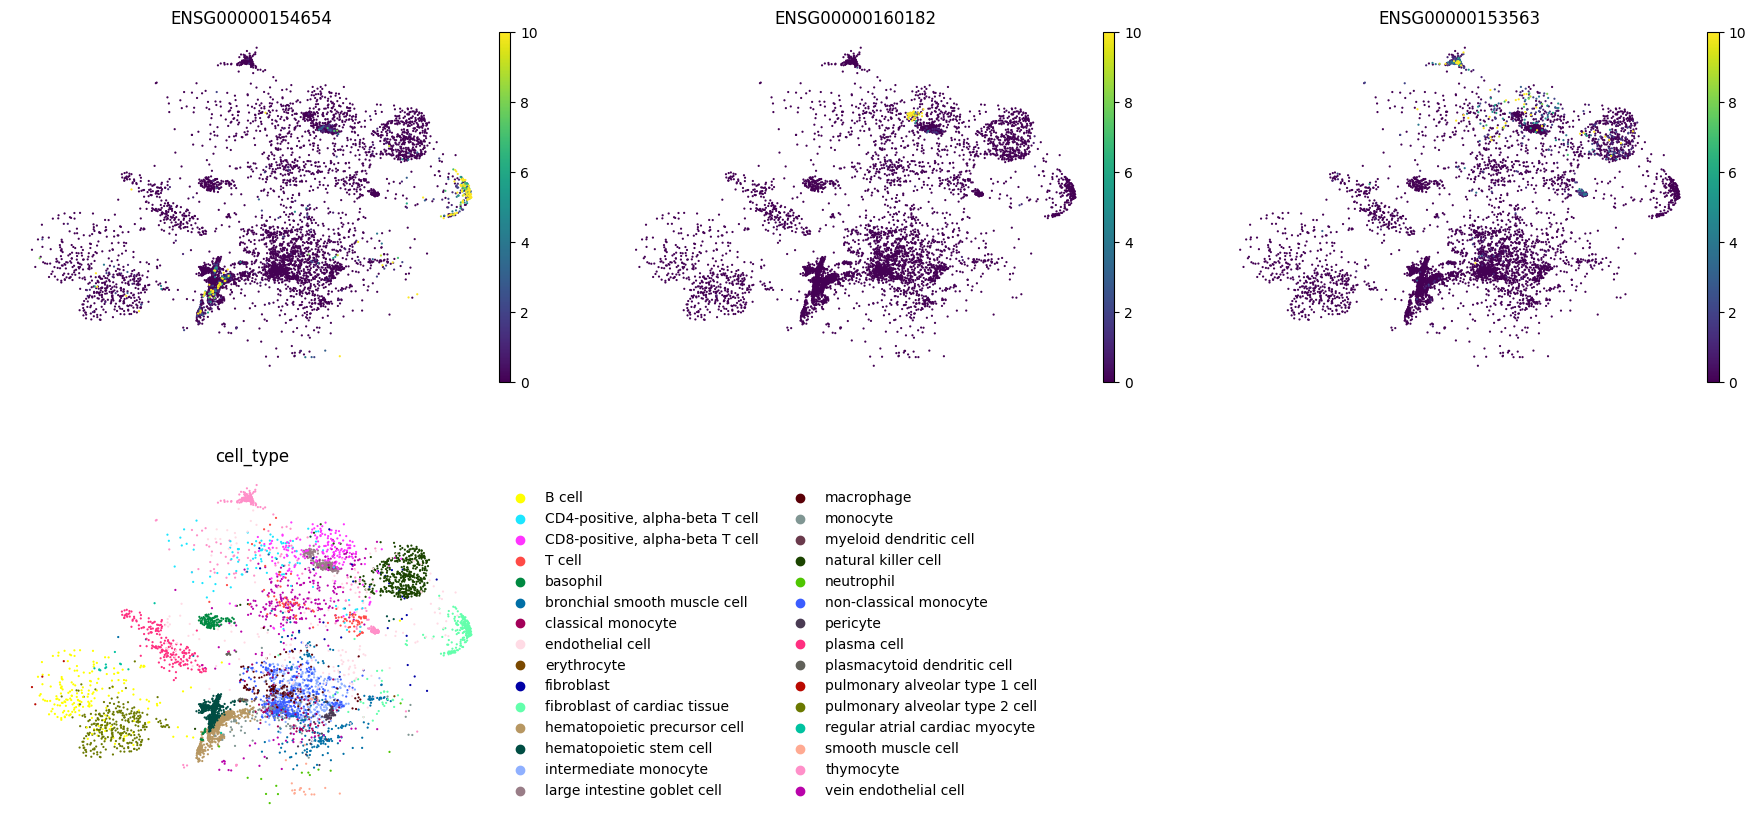

<Figure size 640x480 with 0 Axes>

In [27]:

#cd8_marker_genes = cd8_markers_df.head(6)['names'].tolist()

sc.pl.umap(h, color=["ENSG00000154654", "ENSG00000160182","ENSG00000153563", 'cell_type'],
           ncols=3, frameon=False, s=10, vmax = 10,
           title=["ENSG00000154654", "ENSG00000160182","ENSG00000153563",'cell_type'])
plt.tight_layout()
plt.show()

In [28]:
human_shared.var_names

Index(['ENSG00000154620', 'ENSG00000067048', 'ENSG00000114374', 'ENSG00000183878', 'ENSG00000012817', 'ENSG00000154646', 'ENSG00000156282', 'ENSG00000188694', 'ENSG00000154654', 'ENSG00000156284',
       ...
       'ENSG00000077585', 'ENSG00000143157', 'ENSG00000143515', 'ENSG00000189171', 'ENSG00000152382', 'ENSG00000143740', 'ENSG00000117472', 'ENSG00000168710', 'ENSG00000081692', 'ENSG00000132676'],
      dtype='object', length=14451)

In [29]:
print(h)

AnnData object with n_obs × n_vars = 6495 × 14451
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'deve

In [30]:
sc.pp.highly_variable_genes(h, n_top_genes=1000, flavor='seurat')
hvg_genes = h.var_names[h.var.highly_variable].tolist()

In [31]:
print(hvg_genes)
"ENSG00000081237" in hvg_genes

['ENSG00000154654', 'ENSG00000160182', 'ENSG00000102837', 'ENSG00000118946', 'ENSG00000204442', 'ENSG00000180730', 'ENSG00000102678', 'ENSG00000173482', 'ENSG00000183098', 'ENSG00000154611', 'ENSG00000179399', 'ENSG00000053747', 'ENSG00000091157', 'ENSG00000134443', 'ENSG00000101115', 'ENSG00000196074', 'ENSG00000125879', 'ENSG00000142156', 'ENSG00000101200', 'ENSG00000204103', 'ENSG00000124107', 'ENSG00000133454', 'ENSG00000160180', 'ENSG00000184226', 'ENSG00000102466', 'ENSG00000102554', 'ENSG00000100292', 'ENSG00000178726', 'ENSG00000169508', 'ENSG00000172264', 'ENSG00000184113', 'ENSG00000182463', 'ENSG00000185010', 'ENSG00000149488', 'ENSG00000132965', 'ENSG00000046604', 'ENSG00000118271', 'ENSG00000134871', 'ENSG00000102755', 'ENSG00000159167', 'ENSG00000156687', 'ENSG00000166450', 'ENSG00000147256', 'ENSG00000167139', 'ENSG00000133083', 'ENSG00000147234', 'ENSG00000205038', 'ENSG00000182732', 'ENSG00000197353', 'ENSG00000104415', 'ENSG00000165240', 'ENSG00000156049', 'ENSG000001

False

In [32]:
m.var_names

Index(['ENSG00000154620', 'ENSG00000067048', 'ENSG00000114374', 'ENSG00000183878', 'ENSG00000012817', 'ENSG00000154646', 'ENSG00000156282', 'ENSG00000188694', 'ENSG00000154654', 'ENSG00000156284',
       ...
       'ENSG00000077585', 'ENSG00000143157', 'ENSG00000143515', 'ENSG00000189171', 'ENSG00000152382', 'ENSG00000143740', 'ENSG00000117472', 'ENSG00000168710', 'ENSG00000081692', 'ENSG00000132676'],
      dtype='object', length=14451)

In [ ]:
np.max(h.layers["decontXcounts"])
#np.max(h.layers["scale_data"])

np.int32(1704663)

: 

In [ ]:
# ==============================================================================
# HVG SELECTION  (parameterised by holdout cell type)
# ==============================================================================
import scanpy as sc

def prepare_training_data(
    mouse_adata,
    human_adata,
    holdout_celltype_id=None,
    n_hvg=1000,
):
    """
    Split matched mouse/human AnnData into train and holdout by
    cell_type_ontology_term_id, then select HVGs from training data only.

    Both input AnnData objects must share the same var_names (gene-aligned).

    Returns
    -------
    train_mouse, train_human : AnnData  (HVG-subset training cells)
    hold_mouse,  hold_human  : AnnData or None
    hvg_genes                : list[str]
    """
    m = mouse_adata.copy()
    h = human_adata.copy()

    if holdout_celltype_id is not None:
        m_mask = m.obs['cell_type_ontology_term_id'].astype(str) != holdout_celltype_id
        h_mask = h.obs['cell_type_ontology_term_id'].astype(str) != holdout_celltype_id
        m_train, m_hold = m[m_mask].copy(), m[~m_mask].copy()
        h_train, h_hold = h[h_mask].copy(), h[~h_mask].copy()
    else:
        m_train, h_train = m.copy(), h.copy()
        m_hold = h_hold = None

    print(f"Training cells:  mouse={m_train.n_obs}  human={h_train.n_obs}  "
          f"total={m_train.n_obs + h_train.n_obs}")
    if m_hold is not None:
        print(f"Holdout cells:   mouse={m_hold.n_obs}  human={h_hold.n_obs}  "
              f"total={m_hold.n_obs + h_hold.n_obs}")

    # Doing HVG after the Gene Space Alignment
    # HVG selection on concatenated training data
    combined = ad.concat([m_train, h_train], join='inner')
    sc.pp.highly_variable_genes(combined, n_top_genes=n_hvg, flavor='seurat')
    hvg_genes = combined.var_names[combined.var.highly_variable].tolist()
    print(f"Selected {len(hvg_genes)} HVGs from training data")

    m_train = m_train[:, hvg_genes].copy()
    h_train = h_train[:, hvg_genes].copy()
    if m_hold is not None:
        m_hold = m_hold[:, hvg_genes].copy()
        h_hold = h_hold[:, hvg_genes].copy()

    print(f"Final train shapes:  mouse={m_train.shape}  human={h_train.shape}")
    if m_hold is not None:
        print(f"Final holdout shapes: mouse={m_hold.shape}  human={h_hold.shape}")

    return m_train, h_train, m_hold, h_hold, hvg_genes


HOLDOUT_CELLTYPE = "CL:0000084"  # T cell

print(f"Holdout cell type: {HOLDOUT_CELLTYPE}")
print("=" * 60)
train_m, train_h, hold_m, hold_h, hvgs = prepare_training_data(
    mouse_shared, human_shared,
    holdout_celltype_id=HOLDOUT_CELLTYPE,
    n_hvg=1000,
)
print(f"\nFirst 10 HVGs: {hvgs[:10]}")

Holdout cell type: CL:0000084


In [ ]:
#cd8_marker_genes = cd8_markers_df.head(6)['names'].tolist()

sc.pl.umap(train_h, color=[*hvgs[:10], 'cell_type'],
           ncols=3, frameon=False, s=10,
           title=[*[f'{g} (CD8 marker)' for g in hvgs[:10]], 'cell_type'])
plt.tight_layout()
plt.show()

In [ ]:
# Cell  | condition | cell_type
# ------|-----------|----------
# H1    | human     | T cell        ← holdout (CL:0000084)
# H2    | human     | T cell        ← holdout
# H3    | human     | B cell
# H4    | human     | B cell
# H5    | human     | macrophage
# M1    | mouse     | T cell        ← holdout
# M2    | mouse     | T cell        ← holdout
# M3    | mouse     | B cell
# M4    | mouse     | B cell
# M5    | mouse     | macrophage

In [ ]:
# Group "human" (5 cells) → 80% train, 20% test:
#   train: H1, H2, H3, H4
#   test:  H5 (validation)

# Group "mouse" (5 cells) → 80% train, 20% test:
#   train: M1, M2, M3, M4
#   test:  M5 (validation)

# Total Train: 8
# Total Test/Validation: 2

# Holdout set (all T cells):
# - mouse: M1, M2
# - human: H1, H2

# Simply to make the iid and ood comparable
# Split holdout 50/50:
# - ood    = M1, H1
# - ignore = M2, H2

In [ ]:
# mode="ood" →
#   H1, M1 → "ignore"  (thrown away, not used)
#   H2, M2 → "ood"     (this is the OOD test set)

In [ ]:
# Save as h5ad
# CellOT pipline reads a single h5ad file and handls the OOD splitting
# Via config file

# Needs a condition column to know which are the source and target
# In our case human and mouse

In [ ]:
# ==============================================================================
# SAVE PREPROCESSED DATA AS h5ad  (for SCGen + CellOT pipeline)
# ==============================================================================
import os

train_m.obs['condition'] = 'mouse'
train_h.obs['condition'] = 'human'
hold_m.obs['condition'] = 'mouse'
hold_h.obs['condition'] = 'human'

full_data = ad.concat([train_m, train_h, hold_m, hold_h], join='inner')

# Strip layers/obsm/etc. to ensure compatibility with older anndata (CellOT env)
keep_obs = ['condition', 'cell_type_ontology_term_id', 'cell_type',
            'tissue_ontology_term_id', 'tissue', 'donor_id']
keep_obs = [c for c in keep_obs if c in full_data.obs.columns]
full_data = ad.AnnData(
    X=full_data.X,
    obs=full_data.obs[keep_obs].copy(),
    var=full_data.var[[]].copy(),
)

assert 'condition' in full_data.obs.columns
assert 'cell_type_ontology_term_id' in full_data.obs.columns

outpath = (
    '/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/'
    'cellot/cellot_gpu/datasets/speciesot-human-mouse/hvg-top1k.h5ad'
)
os.makedirs(os.path.dirname(outpath), exist_ok=True)
full_data.write_h5ad(outpath)

print(f"Saved: {outpath}")
print(f"  Shape: {full_data.shape}")
print(f"  Conditions: {dict(full_data.obs['condition'].value_counts())}")
print(f"  Cell types: {full_data.obs['cell_type_ontology_term_id'].nunique()} unique")
print(f"  T cells (CL:0000084): "
      f"{(full_data.obs['cell_type_ontology_term_id'] == 'CL:0000084').sum()}")

T Cell Ontology Inspection

In [ ]:
# ==============================================================================
# T-CELL ONTOLOGY INSPECTION (parents + children inside matched data)
# ==============================================================================
import json
import urllib.parse
import urllib.request
import pandas as pd

T_ROOT = "CL:0000084"  # T cell


def _ols_terms(obo_id: str, relation: str):
    """Fetch ancestor/descendant terms from OLS (OLS4 + legacy fallback)."""
    if relation not in {"ancestors", "descendants"}:
        raise ValueError("relation must be 'ancestors' or 'descendants'")

    iri = f"http://purl.obolibrary.org/obo/{obo_id.replace(':', '_')}"

    # OLS term endpoints expect a double-encoded IRI in the path segment.
    enc1 = urllib.parse.quote(iri, safe="")
    enc2 = urllib.parse.quote(enc1, safe="")

    urls = [
        f"https://www.ebi.ac.uk/ols4/api/ontologies/cl/terms/{enc2}/{relation}?size=1000",
        f"https://www.ebi.ac.uk/ols/api/ontologies/cl/terms/{enc2}/{relation}?size=1000",
        # Fallback for servers that accept single-encoded path
        f"https://www.ebi.ac.uk/ols4/api/ontologies/cl/terms/{enc1}/{relation}?size=1000",
    ]

    payload = None
    last_err = None
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=30) as r:
                payload = json.loads(r.read().decode("utf-8"))
            break
        except Exception as e:
            last_err = e

    if payload is None:
        raise RuntimeError(f"Failed to query OLS for {obo_id}/{relation}. Last error: {last_err}")

    out = []
    for t in payload.get("_embedded", {}).get("terms", []):
        tid = t.get("obo_id")
        lab = t.get("label")
        if tid:
            out.append((tid, lab))
    return out


# Build one table of matched cells across species
m = mouse_matched.obs[["cell_type_ontology_term_id", "cell_type"]].copy()
m["species"] = "mouse"
h = human_matched.obs[["cell_type_ontology_term_id", "cell_type"]].copy()
h["species"] = "human"
matched_obs = pd.concat([m, h], axis=0)
matched_obs = matched_obs.rename(columns={"cell_type_ontology_term_id": "cell_type_id"})

# IDs present in your matched dataset
present_ids = set(matched_obs["cell_type_id"].astype(str).dropna().unique())

# Fetch ontology neighborhood around T cell
anc = _ols_terms(T_ROOT, "ancestors")
des = _ols_terms(T_ROOT, "descendants")
anc_ids = {x[0] for x in anc}
des_ids = {x[0] for x in des}

# Keep only terms that actually appear in your matched dataset
anc_in_data = sorted(present_ids & anc_ids)
des_in_data = sorted(present_ids & des_ids)

print(f"T-cell root: {T_ROOT}")
print(f"Matched dataset unique cell_type IDs: {len(present_ids)}")
print(f"Ancestors of T cell found in matched dataset: {len(anc_in_data)}")
print(f"Descendants of T cell found in matched dataset: {len(des_in_data)}")


def summarize_terms(term_ids, title):
    if not term_ids:
        print(f"\n{title}: none found in matched dataset")
        return pd.DataFrame(columns=["cell_type_id", "cell_type", "mouse_n", "human_n", "total_n"])

    sub = matched_obs[matched_obs["cell_type_id"].isin(term_ids)].copy()
    counts = (
        sub.groupby(["cell_type_id", "cell_type", "species"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    if "mouse" not in counts.columns:
        counts["mouse"] = 0
    if "human" not in counts.columns:
        counts["human"] = 0

    counts = counts.rename(columns={"mouse": "mouse_n", "human": "human_n"})
    counts["total_n"] = counts["mouse_n"] + counts["human_n"]
    counts = counts.sort_values("total_n", ascending=False).reset_index(drop=True)

    print(f"\n{title} (top 20 by cell count):")
    display(counts.head(20))
    return counts

anc_table = summarize_terms(anc_in_data, "T-cell PARENTS in matched dataset")
des_table = summarize_terms(des_in_data, "T-cell CHILDREN in matched dataset")

# Optional: all terms in data with 'T cell' in label (string-based sanity check)
contains_t = matched_obs[matched_obs["cell_type"].astype(str).str.contains("T cell", case=False, na=False)]
print(f"\nString-match sanity check ('T cell' in label): {contains_t['cell_type_id'].nunique()} unique IDs")
display(
    contains_t.groupby(["cell_type_id", "cell_type", "species"]).size().unstack(fill_value=0).reset_index()
)


In [ ]:
# See the AnnData metadata columns available
mouse_matched  # just print it to see obs columns

# Count cells per cell_type + tissue combination
mouse_matched.obs[['cell_type_ontology_term_id', 'tissue_ontology_term_id']].value_counts()
human_matched.obs[['cell_type_ontology_term_id', 'tissue_ontology_term_id']].value_counts()

In [ ]:
human_matched.obs[['cell_type']].value_counts()

In [ ]:
mouse_matched.obs[['cell_type']].value_counts()